predict the selling price of a used car based on features

get the data

In [1]:
import kagglehub 

path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)


Path to dataset files: /Users/zainbabar/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("data/car-details-v4.csv")

In [4]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [5]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

In [7]:
raw_data = data
data = data.dropna()

In [8]:
data.info()

<class 'pandas.DataFrame'>
Index: 1874 entries, 0 to 2057
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   str    
 1   Model               1874 non-null   str    
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   str    
 6   Transmission        1874 non-null   str    
 7   Location            1874 non-null   str    
 8   Color               1874 non-null   str    
 9   Owner               1874 non-null   str    
 10  Seller Type         1874 non-null   str    
 11  Engine              1874 non-null   str    
 12  Max Power           1874 non-null   str    
 13  Max Torque          1874 non-null   str    
 14  Drivetrain          1874 non-null   str    
 15  Length              1874 non-null   float64
 16  Width               18

In [9]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


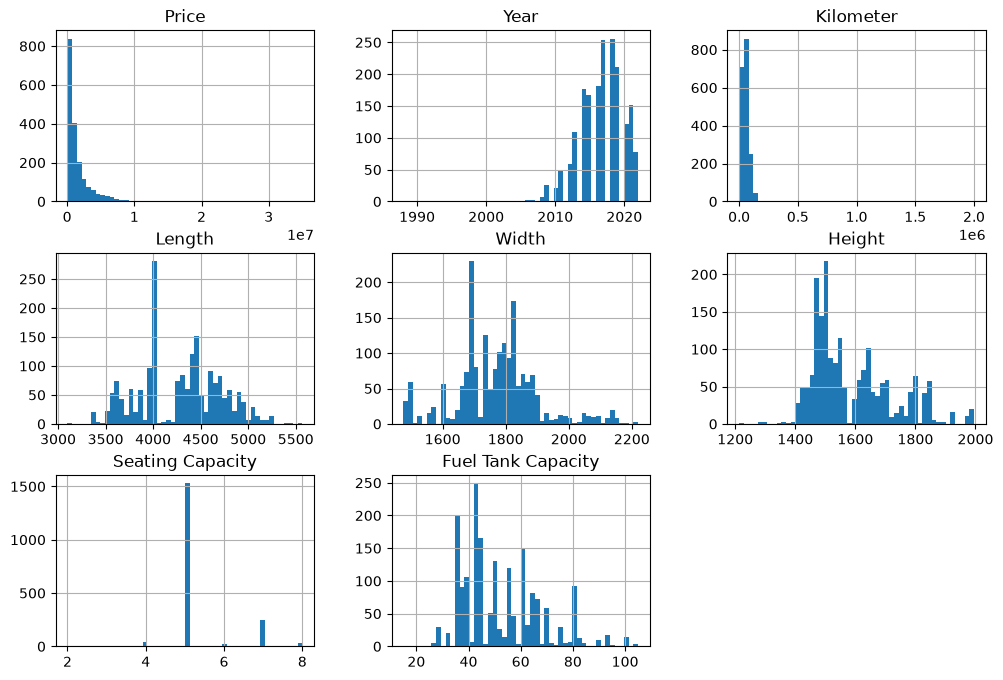

In [10]:
import matplotlib.pyplot as plt

data.hist(bins=50, figsize=(12,8))
plt.show()

split into train/test set, skip stratification for now

In [11]:
features = data.drop(columns=["Price"])
prices = data["Price"]

from sklearn.model_selection import train_test_split

In [12]:

features_train, features_test, prices_train, prices_test = train_test_split(features, prices, test_size=0.2, random_state=42)
train_set = pd.concat([features_train, prices_train], axis=1)

look for correlations

In [13]:
corr_matrix = train_set.corr(numeric_only=True)

In [14]:
corr_matrix["Price"]

Year                  0.318989
Kilometer            -0.143158
Length                0.611532
Width                 0.596076
Height                0.107755
Seating Capacity      0.020716
Fuel Tank Capacity    0.599215
Price                 1.000000
Name: Price, dtype: float64

lookings like strongest numeric indicator is the length/width/fuel tank, implying that larger cars are more expensive. then year. 

but, intuitively we know that the biggest driving factor would probably be the make/model, i.e. luxury cars cost more

In [15]:
counts = train_set["Make"].value_counts()
rare = counts[counts < 10].index # makes that don't appear very often, not very useful for use
train_set["Make"] = train_set["Make"].replace(rare, "Other") # combine all rare makes into an "other" category

In [16]:
train_set = pd.get_dummies(train_set, columns=["Make"], drop_first=True)
train_set.head()

,Model,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,...,Make_Maruti Suzuki,Make_Mercedes-Benz,Make_Nissan,Make_Other,Make_Renault,Make_Skoda,Make_Tata,Make_Toyota,Make_Volkswagen,Make_Volvo
264,Wagon R LXi Minor,2009,39586,Petrol,Manual,Ranchi,Red,First,Individual,1061 cc,...,True,False,False,False,False,False,False,False,False,False
1326,Alto 800 Lx CNG,2017,45000,CNG,Manual,Pune,Silver,First,Individual,796 cc,...,True,False,False,False,False,False,False,False,False,False
1042,Cooper D 3 Door,2018,17000,Diesel,Automatic,Delhi,Green,First,Individual,1496 cc,...,False,False,False,True,False,False,False,False,False,False
794,GLE 300d 4MATIC LWB,2020,18000,Diesel,Automatic,Delhi,Bronze,First,Individual,1950 cc,...,False,True,False,False,False,False,False,False,False,False
1997,City 1.5 E MT,2013,86000,Petrol,Manual,Mumbai,Purple,Second,Individual,1497 cc,...,False,False,False,False,False,False,False,False,False,False


now the make is one hot encoded. 

what else can we do with the data? thinking about it intutively, some things that probably don't affect the price would be seller type, colour, location. engine size could be useful, but we need to convert it to a numeric value, and owner could also be useful. tranmission and fuel type are debatable. 

In [18]:
train_set = pd.get_dummies(train_set, columns=["Transmission"], drop_first=True) 
train_set = train_set.drop(columns=["Color"])

In [21]:
train_set["Owner"].value_counts()

Owner
First               1204
Second               255
Third                 24
UnRegistered Car      16
Name: count, dtype: int64

In [22]:
owner_map = {"First": 1, "Second": 2, "Third": 3, "UnRegistered Car": 4}
train_set["Owner"] = train_set["Owner"].map(owner_map)

some more data cleaning, auto cars would prob cost more than the manuals so one hot that, and drop colour. ordinal encode owners, with unreg being 4, since an unreigstered car would prob cost less.

In [24]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Fuel Type            1499 non-null   str    
 4   Location             1499 non-null   str    
 5   Owner                1499 non-null   int64  
 6   Seller Type          1499 non-null   str    
 7   Engine               1499 non-null   str    
 8   Max Power            1499 non-null   str    
 9   Max Torque           1499 non-null   str    
 10  Drivetrain           1499 non-null   str    
 11  Length               1499 non-null   float64
 12  Width                1499 non-null   float64
 13  Height               1499 non-null   float64
 14  Seating Capacity     1499 non-null   float64
 15  Fuel Tank Capacity   1499 non-null   float64
 16  Pr

In [28]:
train_set = train_set.drop(columns=["Fuel Type", "Location"])


In [27]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Fuel Type            1499 non-null   str    
 4   Location             1499 non-null   str    
 5   Owner                1499 non-null   int64  
 6   Seller Type          1499 non-null   str    
 7   Engine               1499 non-null   str    
 8   Max Power            1499 non-null   str    
 9   Max Torque           1499 non-null   str    
 10  Drivetrain           1499 non-null   str    
 11  Length               1499 non-null   float64
 12  Width                1499 non-null   float64
 13  Height               1499 non-null   float64
 14  Seating Capacity     1499 non-null   float64
 15  Fuel Tank Capacity   1499 non-null   float64
 16  Pr

looking good so far, let's also parse the engine size column to something our model can understand, dropping the cc and converting to an int value

In [29]:
train_set["Engine"] = train_set["Engine"].str.replace(" cc", "", regex=False).astype(int)

In [31]:
train_set["Engine"].info()

<class 'pandas.Series'>
Index: 1499 entries, 264 to 1240
Series name: Engine
Non-Null Count  Dtype
--------------  -----
1499 non-null   int64
dtypes: int64(1)
memory usage: 23.4 KB


now we have to turn the power and torque into integer values too, which will be a little more tricky

In [33]:
train_set["Max Power"] = train_set["Max Power"].str.extract(r"(\d+\.?\d*)").astype(float)
train_set["Max Torque"] = train_set["Max Torque"].str.extract(r"(\d+\.?\d*)").astype(float)

In [34]:
train_set[["Max Power", "Max Torque"]].info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Max Power   1499 non-null   float64
 1   Max Torque  1499 non-null   float64
dtypes: float64(2)
memory usage: 35.1 KB


In [35]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Owner                1499 non-null   int64  
 4   Seller Type          1499 non-null   str    
 5   Engine               1499 non-null   int64  
 6   Max Power            1499 non-null   float64
 7   Max Torque           1499 non-null   float64
 8   Drivetrain           1499 non-null   str    
 9   Length               1499 non-null   float64
 10  Width                1499 non-null   float64
 11  Height               1499 non-null   float64
 12  Seating Capacity     1499 non-null   float64
 13  Fuel Tank Capacity   1499 non-null   float64
 14  Price                1499 non-null   int64  
 15  Make_BMW             1499 non-null   bool   
 16  Ma

so now we only have 3 problematic features: model, seller type, and drivetrain

In [36]:
train_set["Drivetrain"].value_counts()

Drivetrain
FWD    1058
RWD     230
AWD     211
Name: count, dtype: int64

only 3 types, and fwd/rwd/awd have no implied order so one hot seems like the right decision here

In [37]:
train_set = pd.get_dummies(train_set, columns=["Drivetrain"], drop_first=True) 

In [38]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                1499 non-null   str    
 1   Year                 1499 non-null   int64  
 2   Kilometer            1499 non-null   int64  
 3   Owner                1499 non-null   int64  
 4   Seller Type          1499 non-null   str    
 5   Engine               1499 non-null   int64  
 6   Max Power            1499 non-null   float64
 7   Max Torque           1499 non-null   float64
 8   Length               1499 non-null   float64
 9   Width                1499 non-null   float64
 10  Height               1499 non-null   float64
 11  Seating Capacity     1499 non-null   float64
 12  Fuel Tank Capacity   1499 non-null   float64
 13  Price                1499 non-null   int64  
 14  Make_BMW             1499 non-null   bool   
 15  Make_Ford            1499 non-null   bool   
 16  Ma

In [39]:

train_set["Seller Type"].value_counts()

Seller Type
Individual                 1452
Corporate                    44
Commercial Registration       3
Name: count, dtype: int64

3 non ordinal types, looks fine for one hot encoding

In [41]:
train_set = pd.get_dummies(train_set, columns=["Seller Type"], drop_first=True) 

In [42]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Model                   1499 non-null   str    
 1   Year                    1499 non-null   int64  
 2   Kilometer               1499 non-null   int64  
 3   Owner                   1499 non-null   int64  
 4   Engine                  1499 non-null   int64  
 5   Max Power               1499 non-null   float64
 6   Max Torque              1499 non-null   float64
 7   Length                  1499 non-null   float64
 8   Width                   1499 non-null   float64
 9   Height                  1499 non-null   float64
 10  Seating Capacity        1499 non-null   float64
 11  Fuel Tank Capacity      1499 non-null   float64
 12  Price                   1499 non-null   int64  
 13  Make_BMW                1499 non-null   bool   
 14  Make_Ford               1499 non-null   bool   
 15  M

ok now it looks like the only feature our model won't be able to understand is Model. 

In [43]:
train_set["Model"].value_counts()

Model
Swift DZire VDI                      12
City V                               11
X1 sDrive20d xLine                   10
Fortuner 2.8 4x2 AT [2016-2020]      10
Swift DZire VXI                      10
                                     ..
Terrano XV D THP 110 PS               1
Q2 Premium Plus I 40 TFSI quattro     1
Vellfire Hybrid                       1
Kushaq Style 1.0L TSI MT              1
S-Cross Zeta 1.6                      1
Name: count, Length: 829, dtype: int64

tbh there are so many different models of cars that there's no way for use to really encode this in a way a simple model could understand. a more advanced approach could use a neural network to understand the different models, but for now let's just get rid of this feature.

In [45]:
train_set.drop(columns=["Model"], inplace=True)

In [46]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 1499 entries, 264 to 1240
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    1499 non-null   int64  
 1   Kilometer               1499 non-null   int64  
 2   Owner                   1499 non-null   int64  
 3   Engine                  1499 non-null   int64  
 4   Max Power               1499 non-null   float64
 5   Max Torque              1499 non-null   float64
 6   Length                  1499 non-null   float64
 7   Width                   1499 non-null   float64
 8   Height                  1499 non-null   float64
 9   Seating Capacity        1499 non-null   float64
 10  Fuel Tank Capacity      1499 non-null   float64
 11  Price                   1499 non-null   int64  
 12  Make_BMW                1499 non-null   bool   
 13  Make_Ford               1499 non-null   bool   
 14  Make_Honda              1499 non-null   bool   
 15  M

atp we have our final training set that we can use to train the model. one final thing we need to do is apply all these transformations onto the test set, and split into our X_train, y_train. kinda went roundabout here, shouldve done all this before splitting :(

In [47]:
X_train = train_set.drop(columns=["Price"])
y_train = train_set["Price"]

This is just getting the test set to match the training set.

In [49]:
X_test = features_test.copy()

# same steps as train_set, in the same order, reusing the same `rare` list and `owner_map`
X_test["Make"] = X_test["Make"].replace(rare, "Other")
X_test = pd.get_dummies(X_test, columns=["Make"], drop_first=True)

X_test = pd.get_dummies(X_test, columns=["Transmission"], drop_first=True)
X_test = X_test.drop(columns=["Color"])

X_test["Owner"] = X_test["Owner"].map(owner_map)

X_test = X_test.drop(columns=["Fuel Type", "Location"])

X_test["Engine"] = X_test["Engine"].str.replace(" cc", "", regex=False).astype(int)
X_test["Max Power"] = X_test["Max Power"].str.extract(r"(\d+\.?\d*)").astype(float)
X_test["Max Torque"] = X_test["Max Torque"].str.extract(r"(\d+\.?\d*)").astype(float)

X_test = pd.get_dummies(X_test, columns=["Drivetrain"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Seller Type"], drop_first=True)

X_test = X_test.drop(columns=["Model"])

# X_test may be missing some dummy columns that only showed up in train (e.g. a rare Make) -
# reindex to match X_train exactly, filling those with False
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

y_test = prices_test

In [51]:
assert list(X_test.columns) == list(X_train.columns)
X_test.info()
X_test.head()

<class 'pandas.DataFrame'>
Index: 375 entries, 2007 to 910
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    375 non-null    int64  
 1   Kilometer               375 non-null    int64  
 2   Owner                   375 non-null    int64  
 3   Engine                  375 non-null    int64  
 4   Max Power               375 non-null    float64
 5   Max Torque              375 non-null    float64
 6   Length                  375 non-null    float64
 7   Width                   375 non-null    float64
 8   Height                  375 non-null    float64
 9   Seating Capacity        375 non-null    float64
 10  Fuel Tank Capacity      375 non-null    float64
 11  Make_BMW                375 non-null    bool   
 12  Make_Ford               375 non-null    bool   
 13  Make_Honda              375 non-null    bool   
 14  Make_Hyundai            375 non-null    bool   
 15  Ma

,Year,Kilometer,Owner,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,...,Make_Skoda,Make_Tata,Make_Toyota,Make_Volkswagen,Make_Volvo,Transmission_Manual,Drivetrain_FWD,Drivetrain_RWD,Seller Type_Corporate,Seller Type_Individual
2007,2020,9500,1,1950,192.0,400.0,5063.0,1860.0,1494.0,5.0,...,False,False,False,False,False,False,False,True,True,False
1319,2018,79800,1,1582,126.0,260.0,4375.0,1700.0,1475.0,5.0,...,False,False,False,False,False,True,True,False,False,True
1603,2021,13000,1,1950,192.0,400.0,5063.0,1860.0,1494.0,5.0,...,False,False,False,False,False,False,False,True,False,True
301,2019,17000,1,1199,89.0,110.0,3999.0,1734.0,1601.0,5.0,...,False,False,False,False,False,True,True,False,False,True
457,2018,92000,1,1248,74.0,190.0,3995.0,1735.0,1515.0,5.0,...,False,False,False,False,False,False,True,False,False,True


ok cool so now we have our `X_test`, `y_test`, `X_train`, `y_train`

> note: we haven't scaled our data. it doensn't matter for the models we will try right now, however in the future we may need to scale the data.

lets try a very basic linear regression model to get started

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ 183551.59, -1.4 , 162605.49,...,-150939.72, 12806.94, 7280.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](36,)","['Year','Kilometer','Owner',...,'Drivetrain_RWD','Seller Type_Corporate', 'Seller Type_Individual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.704e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [60]:
y_pred = lin_reg.predict(X_test)

In [62]:
print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear models
print("R2: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

Coef:  [ 1.83551587e+05 -1.39976071e+00  1.62605489e+05 -2.57928645e+02
  2.80328769e+04  7.67141458e+02 -5.64272396e+01 -1.37957634e+03
  9.87969297e+02 -7.43892508e+04 -5.41451039e+03  6.14434910e+05
  3.67113158e+04 -1.60236232e+05 -4.27893231e+04  3.68799750e+05
 -1.17395232e+06 -4.87493326e+05  1.31636064e+06 -9.34244353e+05
 -4.15722585e+05  2.15677005e+05  9.99427302e+05  3.74691742e+05
  1.48521440e+06  1.50278503e+05 -2.65437789e+05 -5.37780835e+05
  2.20060961e+05  1.80020264e+05  1.55888742e+05  1.89051172e+05
 -1.42212280e+05 -1.50939718e+05  1.28069374e+04  7.28033910e+03]
Intercept:  -370367478.5918575
R2:  0.5907922316988774
RMSE:  2188704.6919938154


ouch, it looks like our rmse is terrible, we are off by about 2,000,000 each time which is a lil over the mean value

In [66]:
train_pred = lin_reg.predict(X_train)
print(r2_score(y_train, train_pred)) 
print(root_mean_squared_error(y_train, train_pred))

0.7723115191166352
999980.0172078913


looking at our coefs, we see the dummy coefs swing by over a million for the price, a huge change, this doesnt seem right

In [68]:
y_train.describe()

count    1.499000e+03
mean     1.635725e+06
std      2.096359e+06
min      4.900000e+04
25%      5.000000e+05
50%      8.500000e+05
75%      1.850000e+06
max      2.000000e+07
Name: Price, dtype: float64

In [69]:
y_test.describe()

count    3.750000e+02
mean     2.048275e+06
std      3.426061e+06
min      1.300000e+05
25%      4.950000e+05
50%      8.250000e+05
75%      2.370000e+06
max      3.500000e+07
Name: Price, dtype: float64

<Axes: >

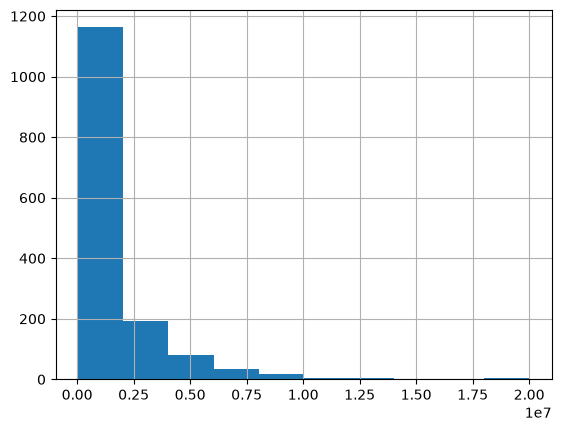

In [71]:
y_train.hist()

<Axes: >

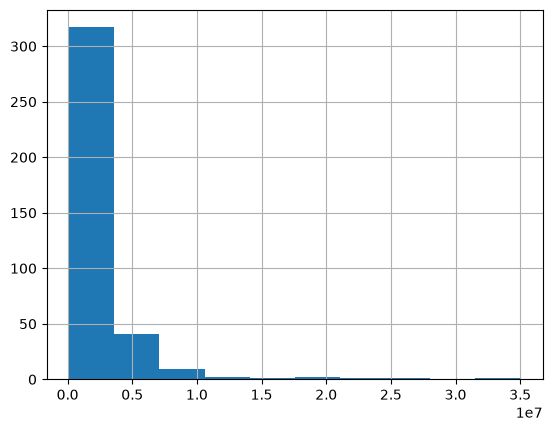

In [72]:
y_test.hist()

another clue is the actual prices, it's heavily skewed with a long right tail, which could be causing some estimates to be way off and extremely punishing in the rmse calculation since we have $$(prediction - actual)^2$$ in the RMSE formula, which blows up disproportionately for outliers

based on this, it looks like our linear regression model isn't performing well due to some issues with the data, so we should do some more feature engineering.

the first thing we can do is fix the heavy right tail (this would also mess up our data if we had decided to scale it so it's a good idea to get rid of it)

<Axes: >

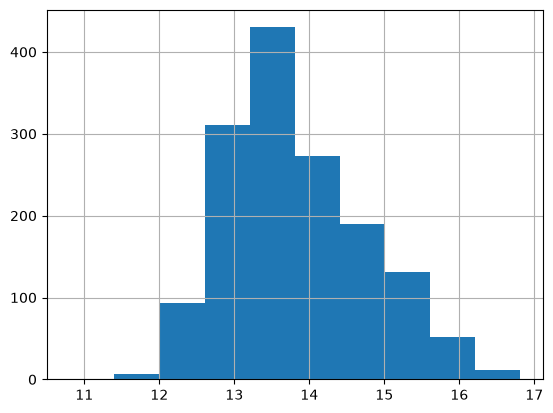

In [75]:
np.log(y_train).hist()

this looks way better, much more of a symetrical, bell shaped (gaussian) distribution. let's replace our train/test prices with their logs

In [81]:
y_train = np.log(y_train)
y_test = np.log(y_test)

now let's retry the linear model to see if log transforming the prices helped to bring down the RMSE

In [82]:
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ 0.01,-0. , 0. ,...,-0.01, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](36,)","['Year','Kilometer','Owner',...,'Drivetrain_RWD','Seller Type_Corporate', 'Seller Type_Individual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-15.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [83]:
y_pred = lin_reg.predict(X_test)

In [84]:
print("Coef: ", lin_reg.coef_) # weights per feature
print("Intercept: ", lin_reg.intercept_) # constant term in linear models
print("R2: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))

Coef:  [ 8.84014787e-03 -2.34896234e-08  5.51863539e-04  4.50218123e-06
  2.11242762e-04  7.19707362e-05  2.90682000e-05  4.64161919e-05
 -3.27547602e-06 -3.13288910e-03  1.68370023e-04  1.53298944e-02
 -7.44314162e-03 -7.00454377e-03 -4.23993692e-03  8.60857684e-03
 -1.03587050e-05  5.29352221e-03  3.34170995e-02 -3.69882483e-03
 -4.68980142e-03 -2.66932241e-03  1.75295295e-02 -9.30694777e-03
  1.25635087e-02 -1.67307281e-02 -5.12155606e-03 -2.08948874e-02
  1.05483975e-02 -1.41735409e-03  2.29084909e-02 -1.42650924e-02
 -7.17777483e-03 -5.48930476e-03  9.89037087e-04 -1.36704818e-04]
Intercept:  -15.435545614451701
R2:  0.9153695190732319
RMSE:  0.021289198280433345


This looks MUCH better, we have a great R2 score and RMSE, looks like the issue was with the heavy right tail in the prices. 